---
title: EDA I
---

::: {note} Learning Outcomes
* Turn a vague request into clarifying questions and a concrete analysis plan
* Judge how far to trust a dataset by asking where it came from and what it leaves out
* Load and inspect a table with `pl.read_csv`, `len()`, `.shape`, and `df["col"]`
* Sort, filter, and add columns with `.sort()`, `.filter()`, and `.with_columns()`
* Summarize one variable with `.describe()`, `.value_counts()`, `sns.boxplot`, and `sns.histplot`
* Describe a distribution's skew and modality, and explain why a boxplot can hide modality
* Write each table operation three ways: in plain English, in Polars, and in SQL
:::

In this chapter, we will take a vague request from a manager and turn it into an analysis. We will find data that could answer the request, ask whether that data can be trusted, and use our first table operations and plots to look for schools that stand out.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# School names run to 35 characters; show them in full rather than cutting them at 30
pl.Config.set_fmt_str_lengths(40)
sns.set_palette("colorblind")

## Exploratory Data Analysis

The first step of working with a dataset is called Exploratory Data Analysis, or EDA for short. We will show what that means through an extended example.

Most of the data we work with in this class is **tabular data**: data that lives in a table. The table below lists the candidates in US presidential elections, and it is typical of what tabular data looks like.

To load it, we use Polars, the Python library for working with tables that we use throughout Data 100. Polars is conventionally imported under the short name `pl` (`import polars as pl`), much as NumPy is imported as `np`; this page does that in a hidden setup cell. `pl.read_csv` reads a CSV file into a `DataFrame`, the Polars object for a table. Ending a cell with the table's name displays it.

In [2]:
elections = pl.read_csv("data/elections.csv")
elections

Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
…,…,…,…,…,…
2024,"""Donald Trump""","""Republican""",77303568,"""win""",49.808629
2024,"""Kamala Harris""","""Democratic""",75019230,"""loss""",48.336772
2024,"""Jill Stein""","""Green""",861155,"""loss""",0.554864


The table has 187 rows and 6 columns. Each row represents one **observation**: here, a single person running for president in a particular year. Each column represents some characteristic, or **feature**, of that observation, such as the candidate's party.

In the second row, we have John Quincy Adams, who ran in 1824. You can see the party he ran under, how many votes he won, the percent of the vote that he got, and whether or not he won. The last rows are the candidates of 2024.

The vast majority of the data we look at in this class will either be tabular, or data that we can reshape into a table.

### Languages and Libraries

In Data 8, you worked with tabular data using the `datascience` library and its `Table`s. In Data 100, we will use a newer industry-standard library called Polars, along with SQL, which you may remember from CS 61A or Data C88C.

Polars is a library for working with tabular data in **DataFrames**. It works in Python, and also in R, Rust and other languages. It is a successor to `pandas`, the long-standing industry standard, and its syntax is similar, so if a future job uses `pandas`, you will be able to learn it on the fly. In spirit, it is also similar to the `datascience` library from Data 8. Polars is fast and scales well to large datasets, which is one reason its popularity is growing quickly.

SQL is a declarative programming language for working with tabular data that lives in databases. Its syntax is completely different from Python's. Most of the SQL in this class will be review from CS 61A or Data C88C, and throughout this chapter we will write each table operation in both Polars and SQL, so that you can see the two side by side.

## Developing Data Science Skills

In the coming sections, we will explore the mental frameworks around manipulating and visualizing tabular data. These frameworks are the same regardless of the tool you work in, whether that is Polars, `pandas`, R, or even Excel. **The goal of Data 100 is not to learn the syntax of Polars (or SQL)**, but to learn the big ideas behind them.

We want you to come away from the next few weeks understanding those big ideas, and able to answer questions such as:
- What do I do when I get a dataset?
- How do I think about manipulating it?

You have to know how to write code to do what we are going to do, and you have to know how to read and understand code. But fundamentally, Data 100 **is not a coding class**.

We are trying to give you a shared language that you can use to tell other people, "Here is what I did to my table." You can also use this clear language to prompt a large language model (LLM) to write code or make a plot for you.

## A Typical EDA Workflow

What does a typical EDA workflow look like? Often, there is some database with many different tables.

- Perhaps you work for a company that has a giant database somewhere in the cloud, holding gigabytes, terabytes, or even petabytes of data.

- That database is **dynamic**: it may be updated constantly, for example after every purchase a customer makes. You use SQL to take a **snapshot** of a few of its tables (or just one), which is their version at a specific moment in time. You then work with that snapshot, perhaps for months.

- You manipulate the data with Polars (or R, `pandas`, Excel, and so on), and use SQL for basic table manipulations.

- You visualize it with a plotting library such as seaborn (or R, matplotlib, Excel, and so on).

- You repeat these steps as necessary, as new questions come up.

**This is a typical data science workflow.** You get some data from a database, work with a snapshot, and see what information you can draw out of it.

## Introducing Our Data and Task

We'll work with an example that you're all familiar with: college admissions.

About 1,700 public schools in California (that is, state-funded schools that charge no tuition) offer 12th grade, and many of their seniors apply directly to UC Berkeley. This path involves three steps, each of which involves a **decision**:
1. Students **apply** to UC Berkeley.
2. UC Berkeley decides whether to **admit** each student who applies.
3. Finally, each admitted student decides whether to **attend** UC Berkeley (that is, to enroll).

We'll focus on this path for our analysis, but it's important to remember it isn't the only one: students can also apply from private schools, out-of-state schools, international schools, community colleges, other colleges, and so on.

### The Task

Suppose you're an analyst working for the UC Berkeley admissions office. Your manager asks you to identify five California public high schools that defy typical patterns of application, admission, and/or attendance. The admissions office wants to visit these schools to figure out what is going really well, or really wrong.

In answering this question, we'll learn a lot along the way about how to approach open-ended questions like this one, which are common in real-world data science. We'll learn how to understand and contextualize data, how to make analysis plans and implement them in code, and how to visualize results.

### Questions Relevant to Our Task

Before writing any code, we should clarify the task. Data analysis is not solving problem sets: your manager is not hiding a correct answer for you to discover. That is a big mindset shift. Data science is about asking good questions and attempting to answer them, and asking questions is a skill that improves with practice. It drives the daily work of a data scientist, and it is tested in interviews, too.

What clarifying questions would you ask your manager before tackling this task? Here are some examples:

- What is the motivation for this task in the first place?
    - Are fewer students attending than we would usually expect?
    - Are we exploring changes in the student population?

- What data can we access?
    - Where do we have to look for relevant data?
    - Who has access to the data we need?

- Why five schools?
    - Why not three, or ten, or some other number?

- Why California public schools specifically?
    - Why not a different state?
    - Why not private schools?
    - Why not transfer students?
    - Why not community colleges?

- What does "typical" mean?
    - Typical in what way? There are so many ways for something to be typical or not.
    - Is "typical" defined across all schools, or just across groups of similar schools?
    - What does it mean to defy typical?

- Out of the three stages we defined, which one do we care about?
    - All of them equally?
    - Some more than others?

- Do we want to look at schools over time, or just in one year?
    - Are we only interested in what is happening right now?
    - Are we interested in the past?
    - Right now, there is an active debate over whether the SAT should be brought back for admissions to the UC system. Do we want to compare data from before the SAT requirement was removed with data from after?

- Are we more interested in high-performing schools or low-performing schools?

These are all important questions to ask, and the answer to every one of them will shape how we go about our analysis. For example, if we care a lot more about high-performing schools than low-performing ones, then we should spend more of our analysis time and effort on the schools that do well.

Most importantly: What kind of data do we have access to? And what data could we request access to? You will see that the answer is often more than you might think.

## Finding Our Data

What data will we work with? The University of California publishes the number of applicants, admitted students, and enrolled students from schools around the world on its [official website](https://www.universityofcalifornia.edu/about-us/information-center/admissions-source-school). The site has data on both freshman admission and transfer admission. Out of the options for freshman admission, we will look at "Counts of fall freshmen by race/ethnicity", and then select "California public high schools" out of the available datasets.

```{image} images/uc_admissions_source_school_website.png
:alt: Screenshot of the University of California admissions-by-source-school page filtered to California public high schools, Fall 2025, Berkeley campus. Each school takes three rows (App, Adm, Enr) with counts in a single column, and low counts are left blank.
:width: 600
```

For each school, the page gives:
- the name of the school
- the city
- the county
- the counts for the three stages, one row each:
    - applied (App)
    - admitted (Adm)
    - enrolled (Enr)

### Explaining Missing Data

Notice that some of the entries on the page are blank. Why might that be? Here are some possible explanations:

- Blank entries could represent zero students who applied, were admitted, or chose to enroll.
- Blank entries could reflect data that the schools or UC could not access or verify.
- Blank entries could be instances where there were too few students for the data to remain anonymous[^1].
    - Imagine a school where one student applied and was not admitted. If you know a student from that school who applied to Berkeley, the UC data would tell you that they were rejected. That is a serious breach of privacy.

In this case, the answer is noted directly below the dataset. A cell is blank when fewer than five students in a given category ("all", or a specific race/ethnicity) applied, or when fewer than three were admitted or enrolled. A lot of the time, it will not be that easy. You may have to go on a whole quest to understand the cause of missing data!

These are important concerns. We cannot do much analysis on schools with blank data, so we will probably have to exclude them from whatever we do. When we exclude missing information, it is important to keep in mind what we are losing. Data from an important subgroup could be missing at a higher rate, and that would affect any subsequent analysis!

[^1]: Seminal research on this problem comes from Latanya Sweeney. Her 2000 study, *Simple Demographics Often Identify People Uniquely*, found that ZIP code, birth date, and sex together are enough to identify most Americans. A few years earlier, she had used the same kinds of information to pick out the medical records of the governor of Massachusetts from supposedly anonymous hospital data. Both stories are worth reading about if you have some extra time.

:::{note} Be Scrappy With Data!
There is a ton of information and data available out there. Much of the time, if you start working on a question and wish that you had access to certain data, it turns out that you do. It is out there as a public dataset, or as a dataset with some limitations. You may just have to talk to the right person, or fill out the right form, to get access to it.

Always try to have the mindset of "Let me try to get access to that data," instead of "Ah, can't do it, don't have the data." You are not helpless! If you want a personal project, try repeating this chapter's analysis for other years, other types of high schools, or other UC campuses.
:::

## Opening Our Data

We will use the public high school data for students admitted in 2025, since the University of California had not yet released the data for 2026. Let's start by looking at it.

Throughout this chapter, each operation on a table appears three ways. First comes a description in plain **English** of what we want to do. Then comes the Polars code, as a live cell whose output is the answer. Last comes the equivalent **SQL** query.

The data is in the CSV file `data/pivoted-ucb-data.csv`, which we read with `pl.read_csv` and store under the name `admissions`.

**English:** Load the dataset and show a preview.

In [3]:
admissions = pl.read_csv("data/pivoted-ucb-data.csv")
admissions

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3
…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null


**SQL:**
```sql
SELECT *
FROM admissions
```

In SQL, the table already lives in a database under the name `admissions`, so there is nothing to load. `SELECT *` asks for every column, and `FROM admissions` names the table.

Let's read the preview from the top. `shape: (1_268, 6)` says that the table has 1,268 rows and 6 columns. Under each column name is its data type: `str` for text, and `i64` for integers (whole numbers). Polars shows the first five rows and the last five, with a row of `…` between them, and it writes `null` where a value is missing.

This table looks different from the website. The website piles the applied, admitted, and enrolled counts into one column, with three rows per school. We pulled them out into a separate column for each step, so that each school is one row. This operation is called a **pivot**, and we will discuss it further at a later time.

Looking at this preview, what do you know about this dataset, and what questions do you have?

Some observations:

- We know the data type of each column (`str`, `i64`).
- There are 1,268 schools in this dataset.
- Several high schools share a name: there are three ABRAHAM LINCOLN HIGH SCHOOLs, in Los Angeles, San Francisco, and San Jose.

Some possible questions:

- How do we work with data where some of the entries are missing, or `null`?
    - We will take a shortcut answer for now, and discuss this in more depth in the future.
- Can we know the size of each graduating class?
    - 201 students from Abraham Lincoln High School in San Francisco applied to UC Berkeley. Does this reflect a huge class, or did almost every student at that school apply?

:::{note} CSV Structure
:open: false

CSV stands for Comma Separated Values, a common way to store tabular data. What does CSV data look like? Here are the first six lines of `pivoted-ucb-data.csv`:

```text
school,city,county,applied,admitted,attended
A B MILLER HIGH SCHOOL,Fontana,San Bernardino,25,3,
ABLE CHARTER,Stockton,San Joaquin,8,,
ABRAHAM LINCOLN HIGH SCHOOL,Los Angeles,Los Angeles,48,11,4
ABRAHAM LINCOLN HIGH SCHOOL,San Francisco,San Francisco,201,33,23
ABRAHAM LINCOLN HIGH SCHOOL,San Jose,Santa Clara,56,8,3
```

The first line contains the column names, separated by commas. Each line after it holds one row's values, in the same order as the names in the first line, and also separated by commas. When a value is missing, there is nothing between two commas: A B MILLER's line ends with a trailing comma, and ABLE CHARTER's ends with two commas in a row. Polars reads these empty fields as `null` values.

Our data could have instead come in other formats, such as TSV (Tab Separated Values) and JSON (JavaScript Object Notation).
:::

While we need code to load and manipulate the data, we want to emphasize the thought process and the English descriptions of what we are doing. Data scientists do more and more of their work by giving LLMs specific instructions in English, rather than writing code from scratch. A plain-language description of each step is helpful both for prompting an LLM and for organizing your own plan. Here, the plain language is that we are **loading the dataset** and **showing a preview of the data**.

:::{note} A Note On Using LLMs
Data scientists still need to read and understand code, both the code that other data scientists share with them and the code that an LLM produces. They also need to check that an LLM's output is correct and does what they wanted. Data 100 is adapting to this: you will spend more time writing precise English instructions and interpreting code, and less time writing code from scratch. You can complete Data 100 without ever using an LLM, but to stay competitive on the job market, we encourage you to develop basic fluency with them.

There are also plenty of reasons to be wary of, skeptical of, or opposed to using LLMs:
- Energy consumption
- Water consumption
- The political and economic activities of the companies that make these models

Relying on an LLM too heavily can also let your own skills slip. These are widely used tools in industry, so it is helpful to learn how to use and prompt them well, but it is important to keep your skills sharp.
:::

## Exploring Our Data

Returning to the topic of asking questions about our data, four kinds of questions will frame the rest of our exploration:

1. **Context and inspection**
    - Do we trust the data? How closely does it correspond to the truth?
        - Any time we analyze data, we are trying to understand some phenomenon in the real world, and data is always an imperfect representation of the real world.
        - In this dataset, schools with very few applicants have no data, so they are not reflected here.

2. **Extremes**
    - Which schools have the highest application, admission, or attendance rates?
        - We saw that 201 students applied from Abraham Lincoln High School in San Francisco. Is that a lot? How does it translate into an application rate?

3. **Distributions and variation**
    - How much do application, admission, and attendance rates differ across schools?
        - Are they all fairly similar, or really spread out? What values do these rates take on across different schools, and why is there variation?

4. **Correlation**
    - Are other characteristics of the schools related to these rates? For example, their distance from UC Berkeley, their average socioeconomic status, the share of their students who are eligible for free or reduced-price meals, and whether they are charter schools.
        - We'll get to correlation at a later point.

### Context and Inspection

We'll start with questions about **data provenance**, which just means where the data comes from. In this case, we got our data from the official UC website.

However, the data we loaded looks different from the data on the website:

- We **pivoted** the website's three rows per school into one row per school, with a column for each stage. No values were changed in the pivot.
- Missing values are shown as `null`, a standard computer science term that means "missing". **Null is not the same as zero.**
- We dropped rows with no visible data. For example, the website lists an Abraham Lincoln High School in Riverside with every count blank, but our dataset has only the ones in Los Angeles, San Francisco, and San Jose.

Was it a good idea to drop those rows entirely? Maybe, maybe not. We will discuss ways to handle missing data a little later.

#### Is the Data Complete?

Do we trust this data? Is it complete? One way to check is to look at the rows with the smallest values, which means we need to **sort** the table.

`.sort` is a `DataFrame` method. It returns a new `DataFrame` with the rows reordered by the values in the column we name. `descending=False` puts the smallest values first (ascending order), and `descending=True` puts the largest first (descending order).

**English:** Sort the dataset in ascending order by the `applied` column.

In [4]:
admissions.sort("applied", descending=False)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""ALTUS CHARTER SCHOOL OF SAN DIEGO""","""San Diego""","""San Diego""",5,null,null
"""ANDERSON VALLEY JR SR HIGH SCHOOL""","""Boonville""","""Mendocino""",5,null,null
"""BIG BEAR HIGH SCHOOL""","""Big Bear City""","""San Bernardino""",5,null,null
"""BOSTONIA GLOBAL""","""El Cajon""","""San Diego""",5,null,null
"""CALIFORNIA CITY HIGH SCHOOL""","""California City""","""Kern""",5,null,null
…,…,…,…,…,…
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29


**SQL:**
```sql
SELECT *
FROM admissions
ORDER BY applied ASC
```

In SQL, `ORDER BY applied ASC` sorts in ascending order, and `ORDER BY applied DESC` sorts in descending order.

The schools at the top of the table had exactly 5 applicants, and most of them have `null` counts for `admitted` and `attended`. That is the UC's rule at work: admission and enrollment counts below 3 are hidden, and schools with fewer than 5 applicants are blank, so we dropped them. Many schools tie at 5 applicants, and `.sort` makes no promise about the order of tied rows, so the particular schools shown at the top are not meaningful.

At the bottom of the table, Dougherty Valley High School in San Ramon has the most applicants, 542. But we don't know whether that reflects a large class size, a large proportion of students applying, or both.

Keep in mind that `.sort` does not modify our original `DataFrame`. If we displayed `admissions` again, we would see the rows in their original order. To keep the sorted version, we would reassign the name to the result: `admissions = admissions.sort("applied", descending=False)`.

#### Counting Rows

How many schools are in the dataset? Python's built-in `len` gives the number of rows in a `DataFrame`.

**English:** Count the number of rows in the dataset.

In [5]:
len(admissions)

1268

**SQL:**
```sql
SELECT COUNT(*)
FROM admissions
```

`COUNT(*)` counts the rows.

We could also use `admissions.shape`, which gives the number of rows and the number of columns as a tuple:

In [6]:
admissions.shape

(1268, 6)

The first item in this tuple is the number of rows, and the second item is the number of columns. To get one of them, we index into the tuple: `admissions.shape[0]` is the number of rows, and `admissions.shape[1]` is the number of columns. Here is the latter:

In [7]:
admissions.shape[1]

6

`admissions.height` gives the number of rows by name, which reads more clearly than `.shape[0]`:

In [8]:
admissions.height

1268

About 1,700 public schools in California offer 12th grade, but our dataset has only 1,268 rows. Why? There are two main reasons. First, schools with no applicants are left out of the UC data entirely. Second, we dropped the rows with no visible data, which are the schools with 1 to 4 applicants. So this data is not complete. *It is important to communicate this to anyone with whom you share this data, or any analysis built on it!*

#### Pulling Out a Column

What is the smallest number of applicants in the dataset? To answer that, we need only the `applied` column. Putting a column's name in square brackets after a `DataFrame` pulls that one column out as a **`Series`**. This may feel familiar from pulling an item out of a `dict` by the name of its key.

In [9]:
admissions["applied"]

applied
i64
25
8
48
201
56
…
86
7
8


A `Series` is a single column with a name and a data type: this one is named `applied`, holds `i64` values, and has 1,268 of them. We use square brackets only for this job, pulling out one column.

A `Series` has methods that summarize its values. `.min()` returns the smallest one.

**English:** Find the minimum of the `applied` column.

In [10]:
admissions["applied"].min()

5

**SQL:**
```sql
SELECT MIN(applied)
FROM admissions
```

The smallest number of applicants is 5, which matches what the sort showed us. The same approach works for many other summaries: `.max()`, `.mean()`, `.median()`, and `.std()` (the standard deviation) in Polars, and `MAX`, `AVG`, and `STDDEV` in SQL.

A `Series` is not a NumPy array, and some of NumPy's summary functions, such as `np.min`, `np.mean`, and `np.std`, raise an error when given one (others, such as `np.median`, happen to work). Use the `Series` method instead, or convert the `Series` to an array with `.to_numpy()` if you really need one.

:::{note} Data Science Wisdom
Data is not necessarily truth. Data can be a good, OK, bad, or incorrect approximation of reality. Just because something is in a neatly organized table does not mean that it's reliable. Be skeptical about your data: Where does it come from? What's missing? How is it limited?

For example, not all public high schools in California are represented in our dataset, and we have limited information about schools with few applicants to UC Berkeley.

However, *do not give up* because of data limitations! Data scientists often have to make do with imperfect data. Be forthcoming about the data's limitations, but push forward.
:::

### Extremes: Counts Are Not Rates

Next, we turn to extremes. Which schools have the highest application rates? A natural first step is to sort in the opposite order, from largest to smallest, so that the schools with the most applicants come first.

**English:** Sort the dataset in descending order by the `applied` column.

In [11]:
admissions.sort("applied", descending=True)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""DOUGHERTY VALLEY HIGH SCHOOL""","""San Ramon""","""Contra Costa""",542,44,32
"""DUBLIN HIGH SCHOOL""","""Dublin""","""Alameda""",435,40,27
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
…,…,…,…,…,…
"""VASQUEZ HIGH SCHOOL""","""Acton""","""Los Angeles""",5,null,null
"""VILLAGE ACADEMY HIGH SCHOOL""","""Pomona""","""Los Angeles""",5,null,null
"""WASHINGTON MIDDLE COLLEGE HS""","""West Sacramento""","""Yolo""",5,null,null


**SQL:**
```sql
SELECT *
FROM admissions
ORDER BY applied DESC
```

Dougherty Valley, Dublin, Arcadia, Lowell, and American High Schools had the most applicants. Does this table answer our question? No! These are application **counts**, not **rates**. A big school can have many applicants even if only a small share of its students apply.

You will often have data that is a count when you actually want a rate, or a rate when you actually want a count. **It's important to keep this distinction in mind, and not get them mixed up!**

The application rate is the number of students who applied, divided by the number of possible applicants:

$$
\text{application rate} = \frac{\text{number who applied}}{\text{number of possible applicants}} \approx \frac{\text{number who applied}}{\text{number of 12th graders}}
$$

Do we have the number of possible applicants in this table? No! The closest thing we can find is the number of 12th graders at each school, and using it is an **assumption**. It treats a school's current 12th graders as its only possible applicants.

## Joining and Using External Data

As noted earlier, we can be scrappy with data. The California Department of Education (CDE) publishes a great deal of data about California's schools on its Data & Statistics page.

```{image} images/cde_data_statistics_website.png
:alt: Screenshot of the California Department of Education's Data & Statistics page, which offers three ways to reach K-12 data: DataQuest, Data Reports, and Downloadable Data Files.
:width: 500
```

While DataQuest and Data Reports are nice for some general purposes, data scientists need raw, downloadable data files that they can manipulate and join to other datasets. So we will use the Downloadable Data Files. Among them is Annual Enrollment, which gives the Census Day enrollment of every school in each grade. From it, we can find the number of 12th graders at each school in the 2024–25 academic year.

```{image} images/cde_annual_enrollment_snippet.png
:alt: Screenshot of the California Department of Education's Annual Enrollment section, describing downloadable files of TK-12 enrollment counts broken down by race/ethnicity, gender, grade, and student program group.
:width: 500
```

To use the number of 12th graders alongside our original dataset, we need to perform an operation called a **join**. A join matches the rows of two tables on some shared information, here the school, to create a new table that has the columns of both. We will discuss joins in greater detail at a later time. In this case, the join is a little tricky, because **high school names can be written differently in different places**: different styles of capitalization, different ways of writing the same word, abbreviations, and so on. We have done the join for you behind the scenes, but matching records like this is an important part of the **data cleaning** process, and a later homework has you work through it.

The joined data is in a new file. We load it under the same name, `admissions`, so from here on the name refers to the new table.

In [12]:
admissions = pl.read_csv("data/pivoted-ucb-data-w-enrollment.csv")
admissions

school,city,county,applied,admitted,attended,tot_enrolled,grade_12
str,str,str,i64,i64,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365
…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139


For every school, we still have our data from earlier: the school, city, and county, and the numbers who applied, were admitted, and attended. The join added two new columns: `tot_enrolled`, the total number of students enrolled at each school, and `grade_12`, the number of 12th graders enrolled at each school. The table has the same 1,268 rows as before. As we will see shortly, some schools have no enrollment data, so their `tot_enrolled` and `grade_12` are `null`.

### Creating New Columns

How do we use this to calculate the application rate? It is the number who applied, divided by the number of 12th graders, computed separately for each school.

`.with_columns` is a `DataFrame` method that returns a new `DataFrame` with columns added. We name each new column with a keyword argument: the argument's name, written without quotes, becomes the column's name, and its value says how to compute the column. To compute with a column inside a method like this, we refer to it with `pl.col`: `pl.col("applied")` is the `applied` column. Dividing one `pl.col` by another divides the two columns element-wise, one row at a time.

**English:** Create a new column with the application rate for each school.

In [13]:
admissions = admissions.with_columns(
    app_rate=pl.col("applied") / pl.col("grade_12")
)
admissions

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,0.153425
…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,0.057554


**SQL:**
```sql
SELECT *, applied / grade_12 AS app_rate
FROM admissions
```

In SQL, `AS app_rate` names the computed column, and `SELECT *,` keeps every existing column alongside it.

The new `app_rate` column is at the right end of the table. For Abraham Lincoln High School in San Francisco, 201 of its 489 12th graders applied, for a rate of about 0.41. Like `.sort`, `.with_columns` returns a new table rather than changing `admissions`, so we reassigned the name to keep the new column. A school with a `null` value of `grade_12` gets a `null` `app_rate`, since there is nothing to divide by.

### Highest Application Rates

We now have our application rate, so we can ask, "Which schools have the highest application rates?" We will again **sort** the table, this time by `app_rate`, in descending order so that the largest values are at the top.

Where should the schools with a `null` rate go? Polars puts `null` values first when it sorts, so the top of our table would be filled with schools that have no rate at all. Passing `nulls_last=True` to `.sort` moves them to the end instead.

**English:** Sort the `DataFrame` by the `app_rate` column in descending order.

In [14]:
admissions.sort("app_rate", descending=True, nulls_last=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""GIRLS ACADEMIC LEADERSHIP ACAD""","""Los Angeles""","""Los Angeles""",40,7,null,66,16,2.5
"""MCFARLAND HIGH SCHOOL""","""Mcfarland""","""Kern""",16,null,null,14,10,1.6
"""ALAMEDA SCIENCE & TECHNICAL INST""","""Alameda""","""Alameda""",42,7,6,167,29,1.448276
"""SCIENCE ACADEMY STEM MAGNET""","""North Hollywood""","""Los Angeles""",38,5,null,513,33,1.151515
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
…,…,…,…,…,…,…,…,…
"""TORRES HS-HUMANITAS ACAD ART &TECH""","""Los Angeles""","""Los Angeles""",8,null,null,null,null,null
"""USC MEDIA & ENGINEERING MAGNET SCH""","""Los Angeles""","""Los Angeles""",7,null,null,null,null,null
"""VILLAGE ACADEMY HIGH SCHOOL""","""Pomona""","""Los Angeles""",5,null,null,null,null,null


**SQL:**
```sql
SELECT *, applied / grade_12 AS app_rate
FROM admissions
ORDER BY app_rate DESC NULLS LAST
```

`NULLS LAST` does the same job in SQL. Some databases, such as DuckDB, put nulls last by default, but others do not (PostgreSQL puts them first when sorting in descending order), so it is safest to write it out.

The schools with no rate are now at the bottom of the table, where their `grade_12` and `app_rate` show `null`.

## Inspecting Anomalies

This is our data, sorted in descending order by `app_rate`, but something is strange. The top school, Girls Academic Leadership Acad, has an application rate of 2.5: 40 students applied, but the school has only 16 12th graders. The next three schools also have rates above 1.

How is it possible to have an application rate over 100%?

Maybe it's not just 12th graders who apply. Maybe some students graduated, took a gap year, and then applied, or maybe somebody applied from 11th grade. Maybe there was a data entry error. It is important to consider whether our data is an incorrect reflection of reality. Are there assumptions we're making about our data that might not be quite right?

It is also important to consider whether you have simply made a mistake, like joining in the wrong school's enrollment, or pulling one of the joined datasets from the wrong year. Any time you look at a dataset and see something weird, you should first check whether it is the result of a mistake on your end.

In this case, the join is the culprit for at least one school: Girls Academic Leadership Acad was matched to a different school's enrollment. A later homework asks you to diagnose it.

### Filtering Rows

Only four schools have these anomalous application rates, and we know there are no more, because the table is sorted in descending order and the fifth school's rate is below 1. For now, we will simply remove those four schools and continue with our analysis. Maybe there's something interesting going on with them, but they all have few 12th graders (33 at most), so we'll leave them out for now.

So, we need to **filter** our dataset. We want to keep only the rows where the application rate is less than or equal to 1, and then sort again.

`.filter` is a `DataFrame` method that keeps the rows where a condition is true and drops the rest. The condition `pl.col("app_rate") <= 1` compares each value of `app_rate` with 1, giving one value per row: `true`, `false`, or `null` where `app_rate` is `null` (more on that below). This is called a **Boolean mask**, and `.filter` keeps only the rows where the mask is `true`.

**English:** Filter the data to rows where `app_rate` is at most 1. Then, sort by `app_rate`.

In [15]:
admissions = admissions.filter(pl.col("app_rate") <= 1)
admissions.sort("app_rate", descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
"""MONTA VISTA HIGH SCHOOL""","""Cupertino""","""Santa Clara""",321,33,25,1636,421,0.76247
"""GRETCHEN WHITNEY HIGH SCHOOL""","""Cerritos""","""Los Angeles""",119,23,13,1018,163,0.730061
"""CALIFORNIA ACAD MATH & SCIENCE""","""Carson""","""Los Angeles""",115,24,11,667,163,0.705521
"""LYNBROOK HIGH SCHOOL""","""San Jose""","""Santa Clara""",314,34,25,1720,448,0.700893
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORVILLE""","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


**SQL:**
```sql
SELECT *, applied / grade_12 AS app_rate
FROM admissions
WHERE applied / grade_12 <= 1
ORDER BY app_rate DESC
```

We reassigned `admissions` to the filtered table, so from here on the name refers to it. It has 1,229 rows, 39 fewer than the 1,268 we started with. Four of the dropped rows are the schools with rates above 1. The other 35 are the schools with a `null` rate: comparing `null` with 1 gives `null`, not true, so `.filter` drops those rows too. To drop missing values on purpose, you could filter with `pl.col("app_rate").is_not_null()`, which is true exactly where `app_rate` is not `null`.

In SQL, filtering happens with the `WHERE` keyword. Notice that the `WHERE` line repeats the calculation `applied / grade_12` instead of using the name `app_rate`. In standard SQL, `WHERE` is evaluated before `SELECT`, so the name `app_rate` is not defined yet when `WHERE` runs, and databases such as PostgreSQL reject `WHERE app_rate <= 1`. DuckDB is more forgiving and accepts it, but repeating the calculation is accepted by every database. `ORDER BY` runs after `SELECT`, so it can use the name.

One more caution about the division itself. `applied` and `grade_12` are both integer columns, and in databases such as SQLite and PostgreSQL, dividing two integer columns drops the remainder, so there you would write `applied * 1.0 / grade_12`. DuckDB keeps the fractional part, as Polars does.

## Defining Success

Now that we've filtered and sorted, do we have an answer to our manager's original request to identify five schools that defy typical patterns? We have the five schools with the highest application rates, after all: Middle College, Monta Vista, Gretchen Whitney, California Acad Math & Science, and Lynbrook.

We certainly have an answer, but is it the best we can do? We haven't defined what we mean by "typical", so we have no baseline against which to compare schools that "defy typical". We haven't looked at admission or attendance at all! Even within application rates, we haven't looked at low application rates, or at the center and spread of the distribution.

Look closely at these five schools, too. Middle College High School is quite small, with only 60 12th graders. California Acad Math & Science looks like a specialized math and science academy.

Are these five a good representation of the different kinds of public schools in California? Maybe, maybe not. To answer that, we need to look at our dataset and understand the overall distribution of application rates.

:::{note} Data Science Wisdom
One of the key tasks of a data scientist is to **define what success means**. You'll often need to transform vague instructions, like "Give me five schools that defy typical patterns of attendance," into concrete goals or metrics. This also means communicating with your boss and other stakeholders about how you defined your metric, and discussing whether that metric makes sense for the project. Data science requires a lot of collaboration and negotiation!
:::

Here are the fundamental operations we have used so far, each described in plain English:

- View a preview of a `DataFrame`.
- Select specific rows or columns.
- Create new columns.
- Filter to specific rows.
- Order the data by the values in a column.
- Join in additional data.

More are coming! We don't need you to memorize every detail of these methods, but to understand them well enough to read code that uses them. If somebody gives you code that filters a table, you should be able to check that it filtered correctly.

## Distributions

In order to talk about "typical", we have to understand how application rates vary from school to school. What is the variation in application rates across schools? A good place to start is a set of **summary statistics**.

`.select` is a `DataFrame` method that keeps only the columns we name, and returns them as a new `DataFrame`. That is different from square brackets: `admissions["app_rate"]` is a `Series`, while `admissions.select("app_rate")` is a `DataFrame` with one column. We can name several columns at once, as in `admissions.select("school", "attended")`. `.describe()` then computes summary statistics for each column of a `DataFrame`.

**English:** Compute summary statistics about `app_rate`.

In [16]:
admissions.select("app_rate").describe()

statistic,app_rate
str,f64
"""count""",1229.0
"""null_count""",0.0
"""mean""",0.160831
"""std""",0.133873
"""min""",0.009901
"""25%""",0.068921
"""50%""",0.112676
"""75%""",0.204082
"""max""",0.833333


**SQL:** Standard SQL has no concise equivalent of `.describe()`, so in most databases we would compute each statistic separately. DuckDB is an exception: its `SUMMARIZE` command reports similar statistics in one statement, with approximate percentiles.

The `statistic` column names each summary. There are 1,229 schools, none with a `null` rate. The mean application rate is about 0.16: on average, about 16% of a school's 12th graders applied to UC Berkeley. The standard deviation is about 0.13. The rows labeled `25%`, `50%`, and `75%` are percentiles: a quarter of schools have a rate below 0.069, half have a rate below 0.113 (the median), and three quarters have a rate below 0.204. The largest rate is 0.833.

Is this helpful? Kind of. It does tell us something about the distribution, but a picture is worth a thousand words. Humans process images a lot faster than text, so we generally want to start with visualizations and look at specific numbers afterwards.

### Boxplots

In particular, we're going to look at a **boxplot**: a visualization with a box, whiskers extending from its ends, and potentially some dots beyond the whiskers.

We draw plots with seaborn, a Python plotting library, which the setup cell imports as `sns`. `sns.boxplot` takes a `DataFrame` and, as `x`, the name of the column to plot. We end each plotting cell with a semicolon, `;`, so that only the plot is displayed.

**English:** Make a boxplot of the values in `app_rate`.

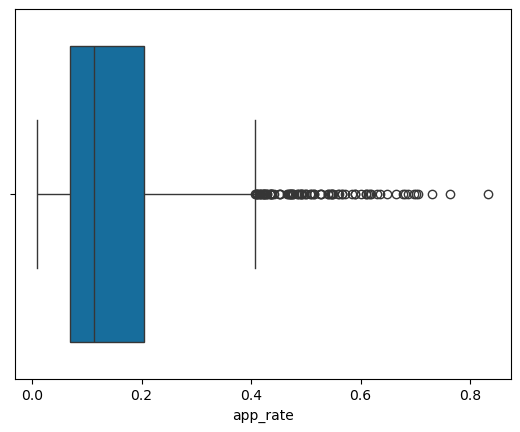

In [17]:
#| fig-alt: Horizontal boxplot of app_rate. The box runs from about 0.07 to 0.20, with the median line near 0.11. The left whisker reaches the minimum, about 0.01, and the right whisker ends near 0.41. Beyond it, dozens of outlier circles stretch to the right as far as about 0.83.
sns.boxplot(admissions, x="app_rate");

There is no SQL for this step: SQL retrieves and manipulates tables, but it does not draw plots.

The box is bounded by the 25th percentile (the first quartile, or Q1) on the left and the 75th percentile (the third quartile, or Q3) on the right, so the middle 50% of the data lives inside it. The line inside the box is the median (the 50th percentile, or second quartile).

The whiskers are defined using the **interquartile range**, IQR = Q3 − Q1, which is the width of the box. A point more than 1.5 × IQR beyond the box, that is, below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR, is considered an **outlier**, and is drawn as its own dot. Each whisker ends at the most extreme data point that is *not* an outlier: the smallest non-outlier on the left, and the largest non-outlier on the right.

The IQR also gives you a measure of how spread out your data is. If the middle half of your data is really spread out, the IQR is big, and if it is tightly packed, the IQR is small.

The figure below labels each part of our boxplot of application rates. Its code computes the quartiles with `.quantile(q)`, which returns the value below which a fraction `q` of a `Series` falls; `interpolation="linear"` matches the way the boxplot itself computes quartiles. `plt` is matplotlib's plotting module, which seaborn draws with and the setup cell imports: `plt.figure(figsize=...)` makes the figure wider. `sns.boxplot` returns the plot it drew, which we call `ax`, and `ax.annotate` writes a label onto that plot, with an arrow pointing to a position.

````{dropdown} Click to see the code
```python
rates = admissions["app_rate"]
q1 = rates.quantile(0.25, interpolation="linear")
median = rates.quantile(0.5, interpolation="linear")
q3 = rates.quantile(0.75, interpolation="linear")
iqr = q3 - q1

# Each whisker ends at the most extreme point within 1.5 * IQR of the box
lower_whisker = admissions.filter(pl.col("app_rate") >= q1 - 1.5 * iqr)["app_rate"].min()
upper_whisker = admissions.filter(pl.col("app_rate") <= q3 + 1.5 * iqr)["app_rate"].max()
n_outliers = admissions.filter(pl.col("app_rate") > q3 + 1.5 * iqr).height

# A wider figure leaves room for the labels
plt.figure(figsize=(10, 4.5))
ax = sns.boxplot(admissions, x="app_rate")

# Each label: its text, the x position it points to, and the height of the text.
# Negative heights are above the box and positive heights are below it.
labels = [
    (f"Q1 = {q1:.3f}", q1, -1.25),
    (f"Median = {median:.3f}", median, -0.8),
    (f"Q3 = {q3:.3f}", q3, -1.25),
    (f"Lower whisker = {lower_whisker:.3f}\n(the minimum)", lower_whisker, 1.1),
    (f"Upper whisker = {upper_whisker:.3f}", upper_whisker, 1.1),
    (f"{n_outliers} outliers, all\nabove Q3 + 1.5 * IQR", 0.65, 1.1),
]
for text, x, height in labels:
    # Point at the top edge of the box from above, or at the whisker line from below
    tip = -0.42 if height < 0 else 0.05
    ax.annotate(text, xy=(x, tip), xytext=(x, height), ha="center",
                arrowprops={"arrowstyle": "->"})

# Make room above and below the box for the labels
ax.set_ylim(1.5, -1.5);
```
````

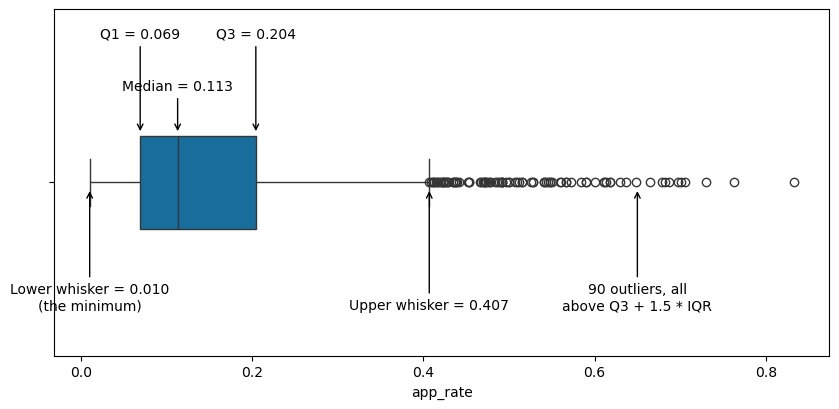

In [18]:
#| fig-alt: The same horizontal boxplot of app_rate, labelled. Above the box, arrows mark Q1 at 0.069, the median at 0.113, and Q3 at 0.204. Below it, arrows mark the lower whisker at 0.010, which is the minimum, the upper whisker at 0.407, and the 90 outlier circles, all above Q3 + 1.5 * IQR, which stretch to about 0.83.
rates = admissions["app_rate"]
q1 = rates.quantile(0.25, interpolation="linear")
median = rates.quantile(0.5, interpolation="linear")
q3 = rates.quantile(0.75, interpolation="linear")
iqr = q3 - q1

# Each whisker ends at the most extreme point within 1.5 * IQR of the box
lower_whisker = admissions.filter(pl.col("app_rate") >= q1 - 1.5 * iqr)["app_rate"].min()
upper_whisker = admissions.filter(pl.col("app_rate") <= q3 + 1.5 * iqr)["app_rate"].max()
n_outliers = admissions.filter(pl.col("app_rate") > q3 + 1.5 * iqr).height

# A wider figure leaves room for the labels
plt.figure(figsize=(10, 4.5))
ax = sns.boxplot(admissions, x="app_rate")

# Each label: its text, the x position it points to, and the height of the text.
# Negative heights are above the box and positive heights are below it.
labels = [
    (f"Q1 = {q1:.3f}", q1, -1.25),
    (f"Median = {median:.3f}", median, -0.8),
    (f"Q3 = {q3:.3f}", q3, -1.25),
    (f"Lower whisker = {lower_whisker:.3f}\n(the minimum)", lower_whisker, 1.1),
    (f"Upper whisker = {upper_whisker:.3f}", upper_whisker, 1.1),
    (f"{n_outliers} outliers, all\nabove Q3 + 1.5 * IQR", 0.65, 1.1),
]
for text, x, height in labels:
    # Point at the top edge of the box from above, or at the whisker line from below
    tip = -0.42 if height < 0 else 0.05
    ax.annotate(text, xy=(x, tip), xytext=(x, height), ha="center",
                arrowprops={"arrowstyle": "->"})

# Make room above and below the box for the labels
ax.set_ylim(1.5, -1.5);

The box runs from 0.069 to 0.204, with the median at 0.113. No school's rate falls more than 1.5 × IQR below Q1, so there are no outliers on the low end, and the lower whisker reaches all the way to the smallest rate, 0.010. On the high end, the whisker stops at 0.407, the largest rate within 1.5 × IQR of Q3, and 90 schools lie beyond it as outliers. So most application rates fall between about 1% and 41%, with a long stretch of unusually high rates beyond that.

What is the minimum possible length of a boxplot whisker? Try to come up with an example dataset that would make the whiskers as short as possible before reading on.

A whisker can have zero length. If no data points fall between Q3 and Q3 + 1.5 × IQR, then every point above Q3 is an outlier, and the boxplot has no upper whisker at all. The same goes for the lower whisker when every point below Q1 is an outlier.

:::{note} Arbitrary Heuristics
Why are outliers defined as points more than 1.5 × IQR beyond the box? This is pretty much an arbitrary decision, but many researchers find it to work fairly well. John Tukey, who popularized the boxplot, reportedly explained the choice this way: 1 was too small, 2 was too big, and 1.5 was just right.

You will find other such "arbitrary, but useful" values. It can be helpful to use them, but there are other times when you will want to think critically about whether they make sense for a given situation!
:::

It is helpful to think about how these visualizations work, and how they would display datasets with different distributions.

### Histograms

We can also look at this data as a **histogram**, which comes with certain advantages and certain disadvantages. `sns.histplot` takes the same arguments as `sns.boxplot`, a `DataFrame` and the column to plot as `x`. It splits the range of values into bins and draws a bar for each bin, whose height is the number of schools with a rate in that bin.

**English:** Make a histogram of the values in `app_rate`.

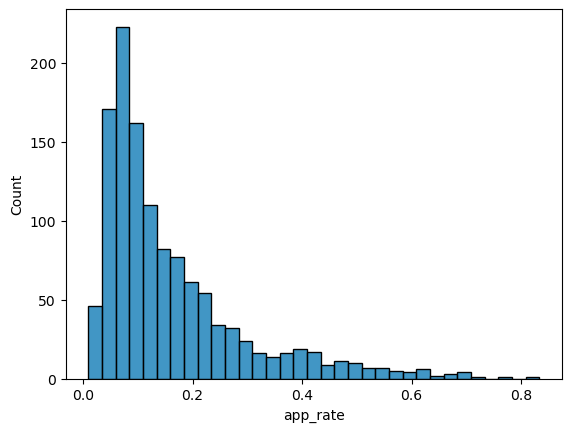

In [19]:
#| fig-alt: Histogram of app_rate, with counts of schools on the y-axis. The tallest bar, a little over 200 schools, sits between about 0.06 and 0.085. To its right, bar heights fall off, leaving a long, thin right tail that reaches about 0.83.
sns.histplot(admissions, x="app_rate");

The tallest bar sits between about 0.06 and 0.085, with a little over 200 schools, and a long right tail stretches past 0.4 all the way to 0.83. In a histogram, the **skew** is the direction in which the tail extends, so this histogram is **right-skewed**, or positively skewed. In a right-skewed distribution, the mean is greater than the median, because the large values in the tail pull the mean toward them much more than they pull the median. Here, as `.describe()` showed, the mean application rate (0.161) is above the median (0.113).

One way to remember the name: a right-skewed histogram looks like a letter P lying on its side, with the P's bowl as the peak and its stem as the long tail to the right. P is for positive skew!

Here are two more examples, drawn from World Bank data on countries. The code creates one figure with two side-by-side panels using `plt.subplots(1, 2)`, which returns the figure and its panels, `axes[0]` and `axes[1]`. Passing `ax=` to a seaborn function tells it which panel to draw on, and `stat="density"` scales the bars so that their total area is 1, instead of showing counts. Each panel's title reports the column's mean and median.

````{dropdown} Click to see the code
```python
wb = pl.read_csv("data/world_bank.csv")
gni = "Gross national income per capita, Atlas method: $: 2016"
water = "Access to an improved water source: % of population: 2015"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(wb, x=gni, stat="density", ax=axes[0])
axes[0].set_title(f"Right skew: mean {wb[gni].mean():,.0f} > median {wb[gni].median():,.0f}")
sns.histplot(wb, x=water, stat="density", ax=axes[1])
axes[1].set_title(f"Left skew: mean {wb[water].mean():.1f} < median {wb[water].median():.1f}");
```
````

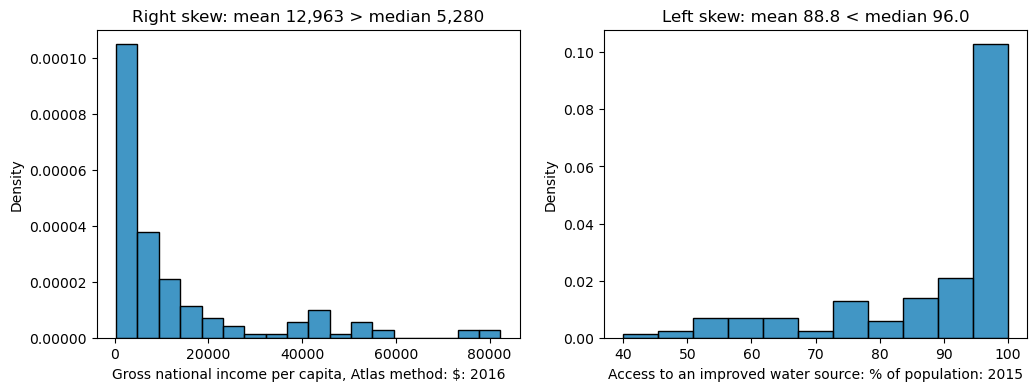

In [20]:
#| fig-alt: Two density histograms side by side. The left panel shows gross national income per capita, with its tallest bar at the far left, under about 5,000 dollars, and a long tail stretching right to about 82,000 dollars, and its title reports a mean of 12,963, above the median of 5,280. The right panel shows access to an improved water source, with its tallest bar at 95 to 100 percent and a long tail stretching left to 40 percent, and its title reports a mean of 88.8, below the median of 96.0.
wb = pl.read_csv("data/world_bank.csv")
gni = "Gross national income per capita, Atlas method: $: 2016"
water = "Access to an improved water source: % of population: 2015"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(wb, x=gni, stat="density", ax=axes[0])
axes[0].set_title(f"Right skew: mean {wb[gni].mean():,.0f} > median {wb[gni].median():,.0f}")
sns.histplot(wb, x=water, stat="density", ax=axes[1])
axes[1].set_title(f"Left skew: mean {wb[water].mean():.1f} < median {wb[water].median():.1f}");

On the left, gross national income per capita piles up near zero, with a long tail to the right. It is right-skewed, and its mean (12,963 dollars) is far above its median (5,280 dollars). On the right, access to an improved water source piles up near 100%, with a long tail to the left. It is **left-skewed**, or negatively skewed, so its mean (88.8%) is below its median (96.0%).

Which one of these is more common in the real world? Right-skewed data happens to be much more common than left-skewed data. Why might that be? Well, a lot of the quantities we work with start at zero and extend upward, such as income.

The **mode** is the most frequent value of a distribution. A distribution with one clear peak is called **unimodal** (as in, a single mode). Our histogram of application rates is unimodal, and so are both of the histograms above. A distribution with two peaks is called **bimodal**, and a distribution with more than two is called **multimodal**.

These labels can be a little fuzzy, because it can be hard to tell whether a bump counts as an additional peak. Consider two more histograms from the World Bank data:

````{dropdown} Click to see the code
```python
diabetes = "Prevalence of diabetes: % of population ages 20 to 79: 2015"
art = "Antiretroviral therapy coverage: % of people living with HIV: 2015"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(wb, x=diabetes, stat="density", ax=axes[0])
axes[0].set_title("Unimodal")
sns.histplot(wb, x=art, stat="density", ax=axes[1])
axes[1].set_title("Bimodal?");
```
````

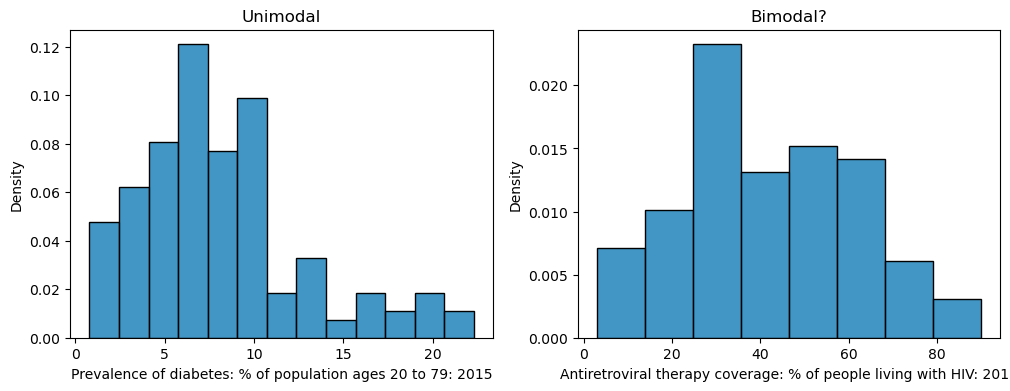

In [21]:
#| fig-alt: Two density histograms side by side. The left panel, titled Unimodal, shows the prevalence of diabetes among adults, one main hump from about 1 to 11 percent with its tallest bar at about 6 to 7 percent and a low tail out to about 22 percent. The right panel, titled Bimodal?, shows antiretroviral therapy coverage, with a tall bar at about 25 to 35 percent, a dip at about 35 to 45 percent, and a second, lower hump at about 45 to 70 percent.
diabetes = "Prevalence of diabetes: % of population ages 20 to 79: 2015"
art = "Antiretroviral therapy coverage: % of people living with HIV: 2015"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(wb, x=diabetes, stat="density", ax=axes[0])
axes[0].set_title("Unimodal")
sns.histplot(wb, x=art, stat="density", ax=axes[1])
axes[1].set_title("Bimodal?");

The prevalence of diabetes, on the left, has one main hump, which rises to its tallest bar at about 6 to 7% of adults. Antiretroviral therapy coverage, on the right, is harder to call. It has a tall bar at about 25 to 35%, then a dip, then a second, lower hump at about 45 to 70%. Is that a second peak, or just noise? The answer depends on how you distinguish peaks and what threshold you use for that distinction. It is up to you to decide how important it is whether the data is unimodal, bimodal, and so on.

Notably, it is impossible to recover this information from a boxplot! This is one major advantage of histograms over boxplots: they give you a more detailed idea of the shape of your data's distribution. However, depending on the bin sizes (how fine-grained your histogram is), a histogram can surface what seem like important patterns or peaks but are really distractions from the overarching pattern, or hide peaks that are really there. We will see this happen shortly.

## Why So Much Variation? Bringing In More Data

Our histogram of application rates raises a new question: why is there so much variation in application rates across schools? Take a moment to think of some reasons before reading on.

There are lots of reasons. The decision to apply is complex. It can depend on money, distance, academic resources, individual and family priorities, and more. Do we have data on any of these?

Not in our current table, but we know where to look. The CDE's Data & Statistics page, which gave us the 12th-grade counts, links to many downloadable data files, organized by topic:

```{image} images/cde_downloadable_files_by_topic.png
:alt: Screenshot of the California Department of Education's list of downloadable data files by topic, from Absenteeism to Student-Level Data Files; the Annual Enrollment, Free or Reduced-Price Meal, and Public School and District links are the three used to extend the admissions data.
:width: 500
```

Three of these topics are useful to us. The first is Annual Enrollment, which is where we got the 12th-grade count. The second is Free or Reduced-Price Meal (Student Poverty), which gives the share of each school's students who are eligible for free or reduced-price meals. That share is a proxy for the average socioeconomic status of a school's students.

```{image} images/cde_frpm_snippet.png
:alt: Screenshot of the California Department of Education's Free or Reduced-Price Meal (Student Poverty) section, which links to files on students eligible for free or reduced-price meals.
:width: 500
```

The third is Public Schools and Districts, from the California School Directory. It gives each school's latitude and longitude, from which we can calculate its distance to Berkeley. It also identifies charter schools, which are public schools with more flexibility, and are often specialized.

```{image} images/cde_public_schools_districts_snippet.png
:alt: Screenshot of the California Department of Education's Public Schools and Districts section, which links to downloadable files about California's public schools and districts from the California School Directory.
:width: 500
```

Joining this data onto our admissions data gives us a new table. As before, we have done the joins for you.

**English:** Load the admissions data joined with the California public schools data.

In [22]:
admissions = pl.read_csv("data/pivoted-ucb-data-w-everything.csv")
admissions

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles
str,str,str,i64,i64,i64,i64,i64,str,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639
…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834


**SQL:**
```sql
SELECT *
FROM admissions
```

We have reassigned `admissions` once more, and it now has 11 columns. It also has all 1,268 schools again: this file was not filtered, so it includes the four schools with rates above 1 and the schools with no enrollment data. It has no `app_rate` column either; the next chapter computes it again. Three columns are new:

- `is_charter`: whether the school is a charter school, `Y` or `N`.
- `pct_free_reduced`: the fraction of the school's students who are eligible for free or reduced-price meals.
- `dist_to_ucb_miles`: the distance from the school to UC Berkeley, in miles, calculated from the school's latitude and longitude.

Let's summarize the new columns before we plot any of them.

**English:** Compute summary statistics about `is_charter`, `pct_free_reduced`, and `dist_to_ucb_miles`.

In [23]:
admissions.select("is_charter", "pct_free_reduced", "dist_to_ucb_miles").describe()

statistic,is_charter,pct_free_reduced,dist_to_ucb_miles
str,str,f64,f64
"""count""","""1233""",1174.0,1233.0
"""null_count""","""35""",94.0,35.0
"""mean""",null,0.53936,236.392646
"""std""",null,0.238296,155.215783
"""min""","""N""",0.034247,0.682117
"""25%""",null,0.340791,67.363956
"""50%""",null,0.562701,316.683921
"""75%""",null,0.734253,362.350757
"""max""","""Y""",0.985318,523.916547


**SQL:** As before, standard SQL has no concise equivalent (DuckDB's `SUMMARIZE` comes close).

For a text column like `is_charter`, `.describe()` can only count the values and report the smallest and largest, here `N` and `Y` in alphabetical order, so its other statistics are `null`. 35 schools have no value for `is_charter` or for `dist_to_ucb_miles`, and 94 have no value for `pct_free_reduced`. The share of students eligible for free or reduced-price meals ranges from 0.034 to 0.985: at some schools almost no students are eligible, and at others almost all are.

:::{tip} Personal Project Idea
Try reproducing these joins from scratch. Download the raw data from the UC and CDE websites, and work out how to match up the schools. An LLM can help you get started!
:::

### Distance to UC Berkeley

What is the variation in distance to UC Berkeley across schools? Let's start with a boxplot.

**English:** Make a boxplot of the values in `dist_to_ucb_miles`.

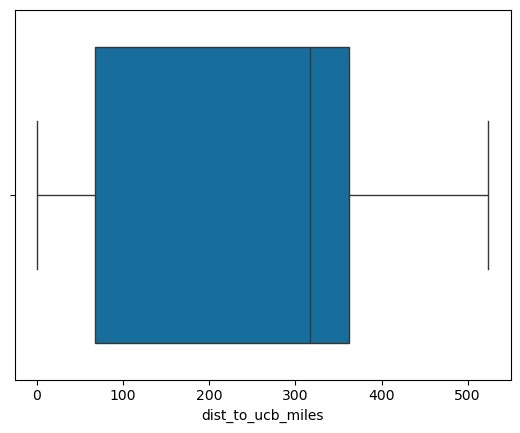

In [24]:
#| fig-alt: Horizontal boxplot of dist_to_ucb_miles with no outlier points. The whiskers run from under 1 mile to about 524 miles. The box runs from about 67 to 362 miles, and the median line sits near 317 miles, much closer to the right end of the box than to the left.
sns.boxplot(admissions, x="dist_to_ucb_miles");

Seaborn silently skips the 35 schools with no distance, so this boxplot describes the other 1,233. There are no outliers: the whiskers run from the closest school, less than a mile from Berkeley, to the farthest, 524 miles away. The box runs from about 67 to 362 miles, and the median, 317 miles, sits much closer to the right end of the box than to the left.

From this boxplot, what do you think the histogram of `dist_to_ucb_miles` looks like? Try sketching it before reading on.

**English:** Make a histogram of the values in `dist_to_ucb_miles`.

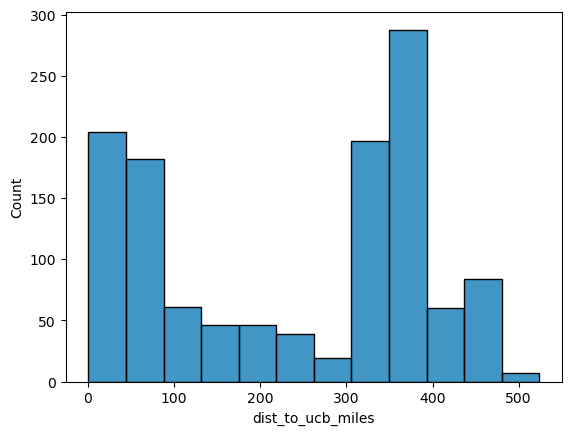

In [25]:
#| fig-alt: Histogram of dist_to_ucb_miles in 12 bins, with counts of schools on the y-axis. Two tall bars of about 200 and 180 schools cover the first 90 miles from Berkeley. Bars stay low, under about 60 schools, from about 90 to 300 miles. The tallest bar, nearly 300 schools, covers about 350 to 390 miles, and a smaller bump of about 85 schools covers about 440 to 480 miles.
sns.histplot(admissions, x="dist_to_ucb_miles");

The histogram shows what the boxplot could not. There is a heap of schools within about 90 miles of Berkeley, relatively few between about 100 and 300 miles, a larger heap between about 300 and 390 miles, and a small bump between about 440 and 480 miles. None of this is visible in the boxplot, whose box simply stretches across the sparse middle.

**Boxplots and histograms are not interchangeable.** Boxplots cannot show modality, the number of peaks, but they are easier to glance at.

Seaborn chose 12 bins for this histogram. Adding more bins shows more detail: `bins=50` tells `sns.histplot` to split the range into 50 equal-width bins instead.

**English:** Make a histogram of the values in `dist_to_ucb_miles`, using 50 bins.

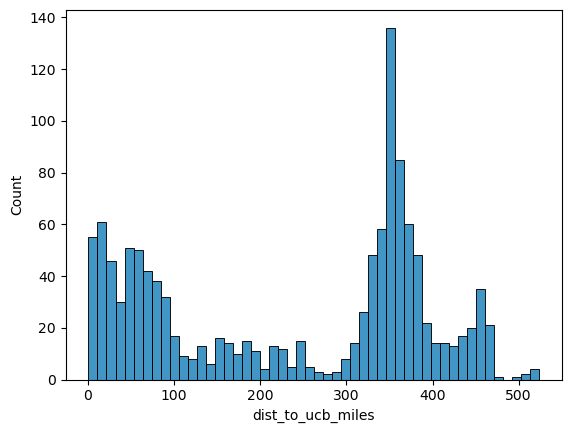

In [26]:
#| fig-alt: Histogram of dist_to_ucb_miles in 50 bins. A broad first peak covers the first 95 miles from Berkeley, with bars of 30 to about 60 schools. Bars stay low from about 100 to 300 miles. A tall, narrow second peak reaches more than 130 schools at about 350 miles, and a smaller third peak of about 35 schools sits near 455 miles. Almost no schools are farther than 470 miles.
sns.histplot(admissions, x="dist_to_ucb_miles", bins=50);

With 50 bins, there are three peaks: a broad one within about 100 miles of Berkeley, a tall, narrow one at about 350 miles, whose tallest bar holds more than 130 schools, and a smaller one at about 455 miles.

### Connecting Plots to the Real World

Why are there three peaks (that is, three modes, or a **trimodal** distribution)? A plot's shape has a cause in the real world, so let's go and find it. There are three population hubs in California: the Bay Area, Los Angeles and Orange County, and San Diego.

```{image} images/california_population_density_map.png
:alt: Map of California population density by census tract from the 2020 Census. The darkest red, most densely populated areas are the Bay Area, Los Angeles and Orange County, and San Diego, which match the three peaks in the distance-to-Berkeley histogram.
:width: 500
```

California population density by census tract, from the 2020 Census.

The three peaks line up with those hubs: the first with the Bay Area, around Berkeley itself, the second with Los Angeles and Orange County, and the third with San Diego. We can check this against the data by counting the schools in each city.

`.value_counts` counts how many times each value appears in a `Series`. It returns a `DataFrame` with two columns: the values themselves, here in a column named `city`, and how many times each one appears, in a column named `count`. `sort=True` puts the most common values first. `.head(5)` then keeps the first five rows of a table.

**English:** For each city, count the number of rows. Show the five cities with the most rows.

In [27]:
admissions["city"].value_counts(sort=True).head(5)

city,count
str,u32
"""Los Angeles""",112
"""San Diego""",41
"""San Jose""",31
"""Oakland""",28
"""Sacramento""",28


**SQL:**
```sql
SELECT city, COUNT(*) AS count
FROM admissions
GROUP BY city
ORDER BY count DESC
LIMIT 5
```

In SQL, `GROUP BY city` gathers the rows for each city into a group, so that `COUNT(*)` counts the rows in each group rather than in the whole table. `LIMIT 5` keeps the first five rows of the result.

Los Angeles has by far the most schools, 112, followed by San Diego with 41 and San Jose with 31. Oakland and Sacramento tie with 28 each, so the order of those two in the table is arbitrary. Los Angeles schools make up much of the second peak, and San Diego schools the third. Oakland, which borders Berkeley, and San Jose and Sacramento, which are both a short drive away, all fall in the broad first peak.

## Back to Application Rates

Let's return to our histogram of application rates, and the question it raised: why is there so much variation in application rates across schools? There are lots of reasons, and this is a hard question. Money, distance, academic resources, and individual and family priorities can all play a part, and we now have columns that stand in for some of them.

Recall our four kinds of questions: context and inspection, extremes, distributions and variation, and correlation. So far, we have asked whether we can trust our data, looked for extremes, and examined distributions. That leaves correlation. A good starting point is to ask how application rates relate to the share of a school's students who are eligible for free or reduced-price meals, `pct_free_reduced`. We will start there in the next chapter.